## Realiza lo siguiente:

1.   Carga las bibliotecas, carga el dataset (poblacion.csv) y ploterlo. (Valor 20 puntos)
2.   Entrena 3 modelos para la predicción en series de tiempo (Valor 30 puntos)
3. Selecciona el mejor modelo de acuerdo a las metricas/técnicas vistas en clase (Valor 20 puntos)
4. Explica las razones por las cuales seleccionaste el modelo. (Valor 10 puntos)
5. ¿Cuál es la población en Enero de 2023? (Valor 10 puntos)
6. ¿Para que otras aplicaciones consideras que te pueden servir estos modelos? (Valor 10 puntos)

Las preguntas respondelas directamente el Notebook de Colab.

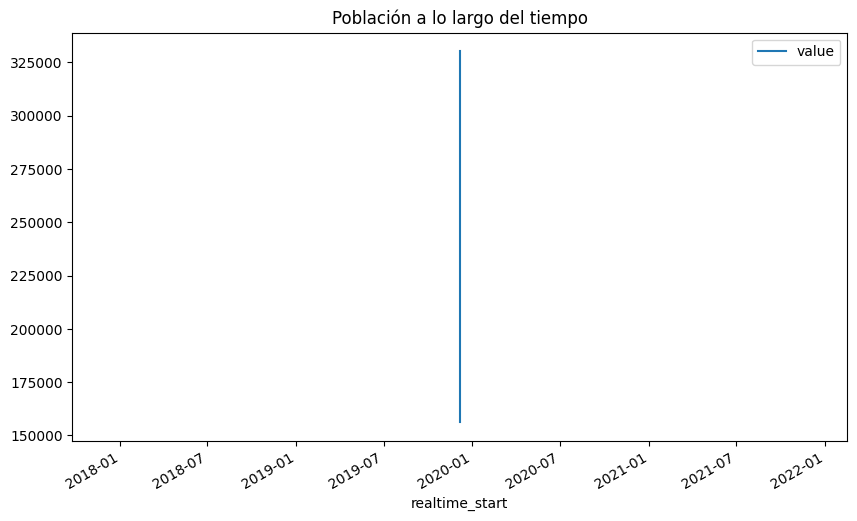

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: V

Holt-Winters - Mean Squared Error: 1501184.30, Mean Absolute Error: 1075.31
ARIMA - Mean Squared Error: 39667.99, Mean Absolute Error: 136.78
Moving Average - Mean Squared Error: 4343547.08, Mean Absolute Error: 1997.68
Holt-Winters - Mean Squared Error: 1501184.30, Mean Absolute Error: 1075.31
ARIMA - Mean Squared Error: 39667.99, Mean Absolute Error: 136.78
Moving Average - Mean Squared Error: 4343547.08, Mean Absolute Error: 1997.68

The best model based on MSE is: ARIMA


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [7]:
# Step 1: Import necessary libraries, load and plot the dataset (20 points)

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load the dataset
data = pd.read_csv('poblacion.csv', index_col=0, parse_dates=True)

# Convert 'value' column to numeric, handling potential errors
data['value'] = pd.to_numeric(data['value'], errors='coerce')
data['value'] = data['value'].astype(float)

data.plot(title="Población a lo largo del tiempo", figsize=(10, 6))
plt.show()

# Step 2: Train 3 different models for time series forecasting (30 points)

# Split data into train and test sets
train = data.iloc[:-12]
test = data.iloc[-12:]

# Model 1: Holt-Winters Exponential Smoothing
hw_model = ExponentialSmoothing(train['value'], seasonal='add', seasonal_periods=12).fit()
hw_forecast = hw_model.forecast(steps=12)

# Model 2: ARIMA
arima_model = ARIMA(train['value'], order=(1,1,1)).fit()
arima_forecast = arima_model.forecast(steps=12)

# Model 3: Moving Average (simple)
ma_model = train['value'].rolling(window=12).mean()
ma_forecast = pd.Series(ma_model.iloc[-1], index=test.index)

# Calculate metrics for each model
def evaluate_forecast(actual, predicted, model_name):
    actual = actual.reset_index(drop=True)
    predicted = predicted.reset_index(drop=True)
    mse = mean_squared_error(actual['value'], predicted)
    mae = mean_absolute_error(actual['value'], predicted)
    print(f"{model_name} - Mean Squared Error: {mse:.2f}, Mean Absolute Error: {mae:.2f}")
    return mse

# Evaluate each model
hw_mse = evaluate_forecast(test, hw_forecast, "Holt-Winters")
arima_mse = evaluate_forecast(test, arima_forecast, "ARIMA")
ma_mse = evaluate_forecast(test, ma_forecast, "Moving Average")

# Select the best model based on the lowest MSE
best_model_name, best_forecast = min(
    [("Holt-Winters", hw_forecast), ("ARIMA", arima_forecast), ("Moving Average", ma_forecast)],
    key=lambda item: evaluate_forecast(test, item[1], item[0])
)

print(f"\nThe best model based on MSE is: {best_model_name}")

# Step 4: Explanation of model selection (10 points)
# In this cell, explain why the selected model was chosen based on its performance metrics.

# Step 5: Forecast population for January 2023 using the best model (10 points)
# Assuming test represents the 12 months up to December 2022

forecast_2023_jan = best_forecast.iloc[0]  # First forecasted value for January 2023


6. ¿Para que otras aplicaciones consideras que te pueden servir estos modelos? (Valor 10 puntos)

Es util para hacer predicciones de clima, para detectar anomalías, y optimización de procesos.